In [1]:
import torch 
import numpy as np 
import matplotlib.pyplot as plt
from itertools import islice
import json

from cryo_sbi.wpa_simulator.cryo_em_simulator import cryo_em_simulator
from cryo_sbi import CryoEmSimulator
from cryo_sbi.inference.models import build_models
import cryo_sbi.utils.estimator_utils as est_utils
from cryo_sbi.inference.priors import get_image_priors, PriorLoader

In [46]:
models = torch.load("../models.pt")
image_config = "simulation_parameters.json"
simulation_batch_size = 160
n_workers=4
device="cuda"
BATCH_SIZE = 32
images = torch.load("../images.pt")

In [47]:
estimator = est_utils.load_estimator(
    "../training_parameters_nle.json",
    build_models.build_nle_flow_model,
    "../tutorial_estimator.pt",
    device="cuda",
)

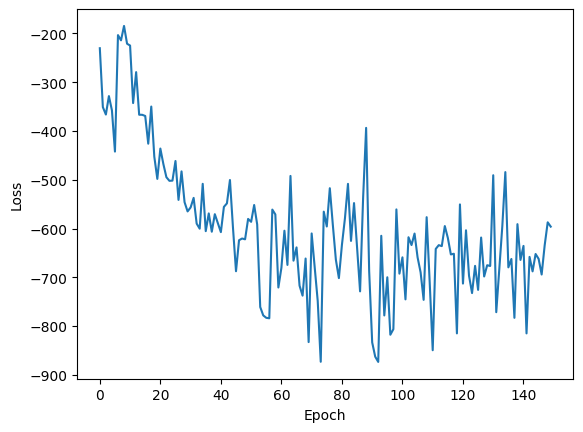

In [48]:
plt.plot(torch.load("../tutorial.loss"))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [49]:
def evaluate_log_prob(estimator, images, theta, device="cuda"):
    """
    Computes the log-likelihood matrix: all θ × all images.
    Flow is conditioned on theta (NLE setup).

    Args:
        estimator: NLEWithEmbedding trained model
        images: torch.Tensor of shape [num_images, H, W]
        theta: torch.Tensor of shape [num_thetas, ...]
        device: device to compute on

    Returns:
        log_probs: [num_thetas, num_images] tensor
    """
    estimator.eval()
    num_images = images.shape[0]
    num_thetas = theta.shape[0]

    log_probs_all = torch.empty(num_thetas, num_images)

    with torch.no_grad():
        for img_idx, image in enumerate(images):
            image_flat = image.view(1, -1).to(device)  # flatten like in training
            
            # Flow conditioned on each θ gives a distribution over images
            posterior = estimator.flow(theta.to(device))  # θ-conditioned flow
            # Evaluate the likelihood of this image under all θ
            log_probs_all[:, img_idx] = posterior.log_prob(image).cpu()

    return log_probs_all

In [50]:
def evaluate_log_prob_2(estimator, images, theta, device="cuda"):
    """
    Computes the log-likelihood matrix: all θ × all images.
    Flow is conditioned on theta (NLE setup).

    Args:
        estimator: NLEWithEmbedding trained model
        images: torch.Tensor of shape [num_images, C, H, W]
        theta: torch.Tensor of shape [num_thetas, param_dim]
        device: device to compute on

    Returns:
        log_probs: [num_thetas, num_images] tensor
    """
    estimator.eval()
    images = images.to(device)
    theta = theta.to(device)
    
    num_images = images.shape[0]
    num_thetas = theta.shape[0]

    log_probs_all = torch.empty(num_thetas, num_images)

    with torch.no_grad():
        # Compute θ-conditioned flows for all θ at once
        # The flow distribution returns log_prob for a batch of images
        for img_idx, image in enumerate(images):
            # Keep image in its original shape, add batch dim
            image_batch = image.unsqueeze(0)  # [1, C, H, W]
            
            # Compute log-probs for this image under all θ
            log_probs = estimator(image_batch.repeat(num_thetas, 1, 1, 1), theta)
            # log_probs shape: [num_thetas, 1], squeeze to [num_thetas]
            log_probs_all[:, img_idx] = log_probs.squeeze(-1).cpu()

    return log_probs_all


In [51]:
log = evaluate_log_prob_2(estimator, images, models, device="cuda")


In [52]:
print(log.shape)


torch.Size([100, 5000])


In [53]:
np.save('log_prob',log)


In [54]:
log = np.load('log_prob.npy')

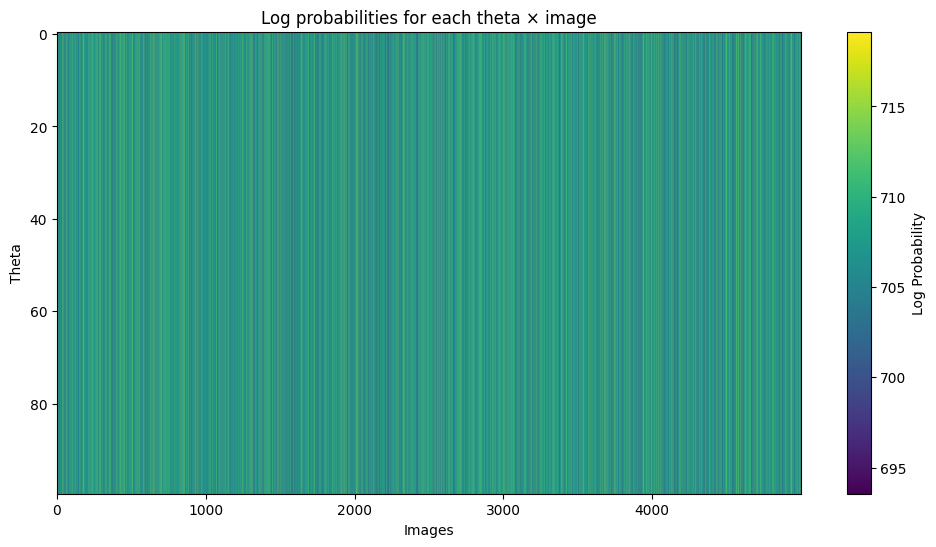

In [56]:
plt.figure(figsize=(12, 6))
plt.imshow(log, aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta')
plt.title('Log probabilities for each theta × image')
plt.show()

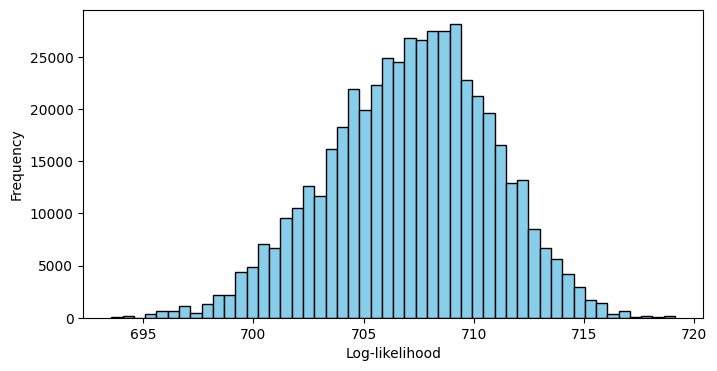

In [57]:
plt.figure(figsize=(8,4))
plt.hist(log.flatten(), bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Log-likelihood")
plt.ylabel("Frequency")
plt.show()

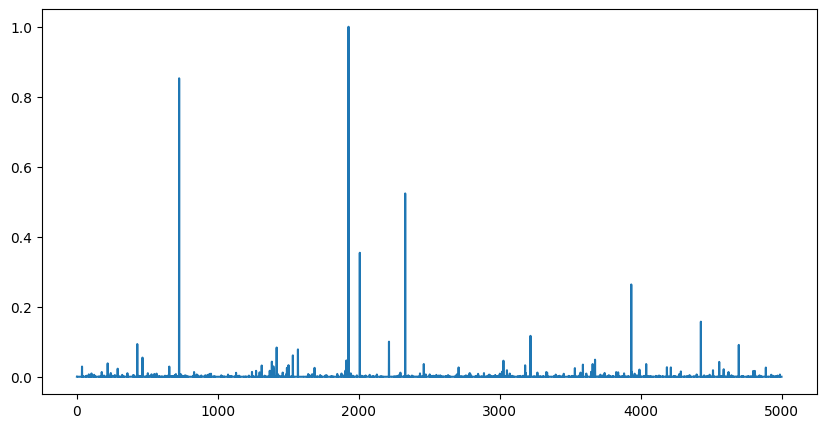

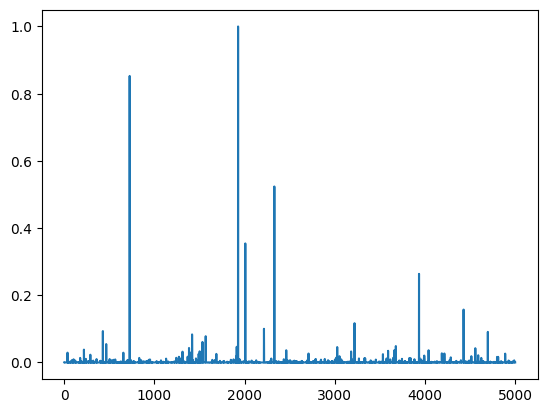

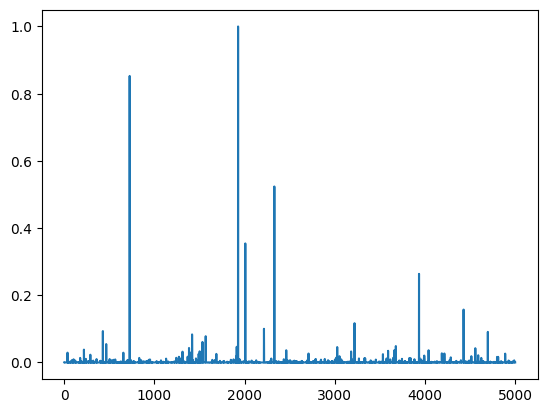

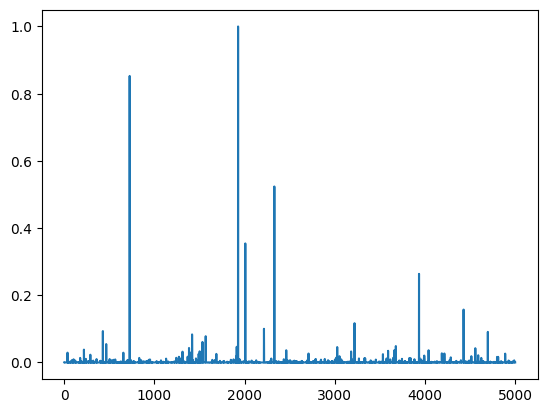

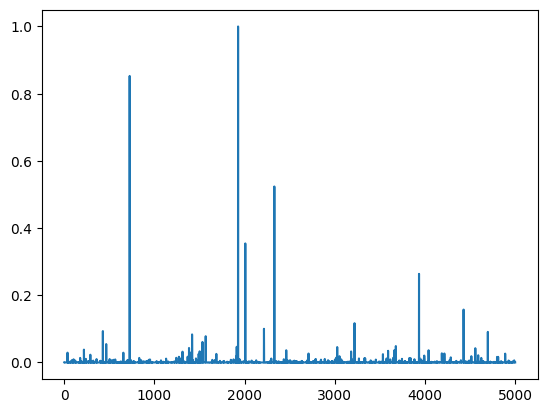

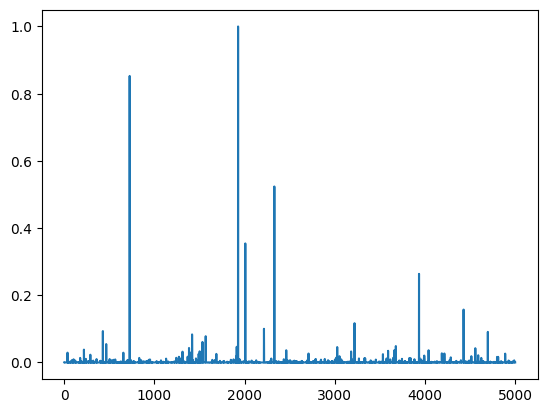

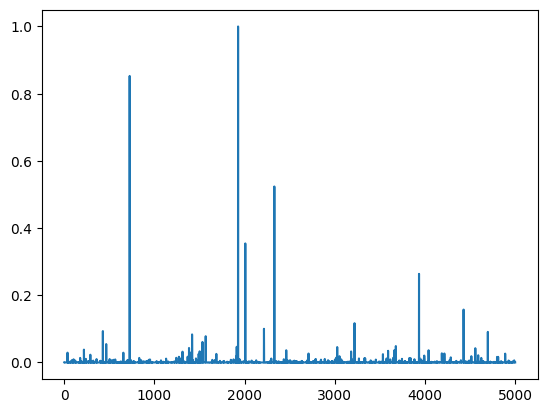

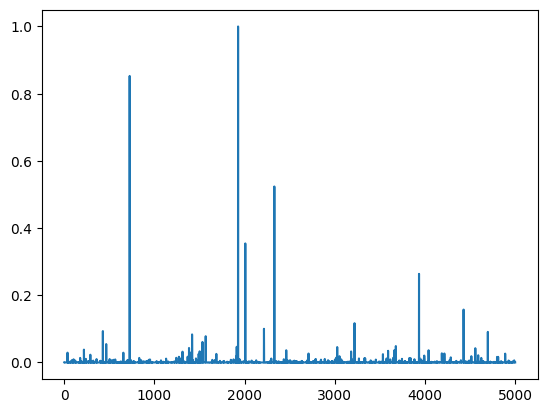

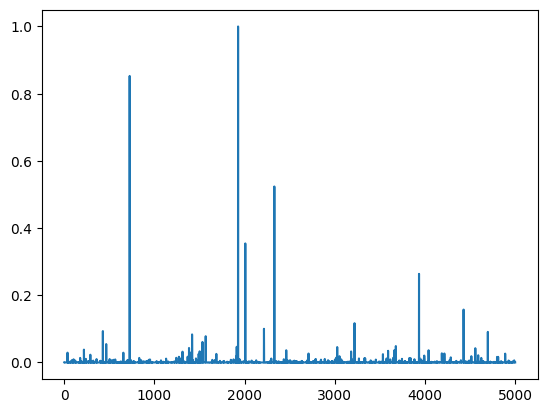

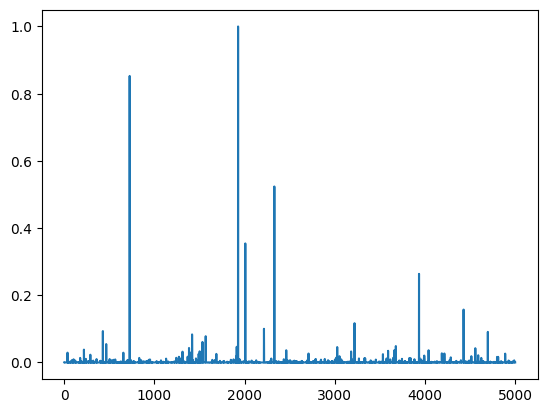

/tmp/ipykernel_236146/3504270936.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


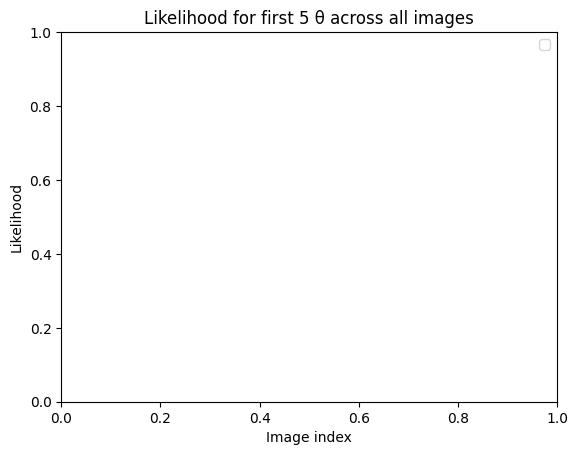

In [58]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.plot(np.exp(log[i] - np.max(log[i])), label=f"theta {i}")
    plt.show()
plt.xlabel("Image index")
plt.ylabel("Likelihood")
plt.title("Likelihood for first 5 θ across all images")
plt.legend()
plt.show()